In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

from rich import print

import os, sys
sys.path.append(os.path.abspath("../@myLib"))
from gaussian_filter import gaussian_filter


## CREACIÓN DEL FILTRO - RESUMEN
- Seleccionar WINDOW SIZE (ej.: 80 puntos, k = 40)
- Convertir WINDOW SIZE a unidades de tiempo, dividiendo por SAMPLE_RATE  (ej.: 80/1000 Sa/s = 80 ms)
- Crear el *vector de tiempos* t:

    ```python 
    t = 1000 * np.arange(-k, k+1) / srate    # ms
    ```

- Seleccionar Full Width at Half Maximum FWHM (ej.: 25 ms) del filtro gausiano
- Crear el kernel gausiano:

    ```python
    gauswin = np.exp(-(4 * np.log(2) * t ** 2) / fwhm ** 2)   # vector de pesos del filtro
    gauswin_norm = gauswin / np.sum(gauswin)   # vector de pesos normalizado
    ``` 

- Aplicar el filtro a la señal

    ```python
    n = len(signal)  # signal[] = f(t[])

    filtsigG = signal.copy()  # initialize filtered signal

    for i in range(k+1, n-k):  #  i: punto central
        filtsigG[i] = np.sum(signal[ i-k : i+k+1 ] * gauswin)  # promedio ponderado 
    ``` 

In [110]:
def ejes():
    plt.axhline(0, color='black', lw=0.5)
    plt.axvline(0, color='black', lw=0.5)
    plt.grid(alpha=0.5)
    plt.tight_layout()

In [111]:
# Constants
PATH = "../@data/roz.csv"

In [112]:
df0 = pd.read_csv(PATH, sep="\t", header=0)
df0.head()

,ts,Sample#,A,B,dx,F
0,254451622.0,0.0,-43.75692,-29.44337,15.27346,0.09157
1,254451640.0,1.0,-43.76684,-29.44833,15.41719,0.08699
2,254451656.0,2.0,-43.71970,-29.43593,15.42845,0.08699
3,254451715.0,3.0,-43.75940,-29.46074,15.43485,0.08852
4,254451732.0,4.0,-43.70481,-29.45578,15.42967,0.08699


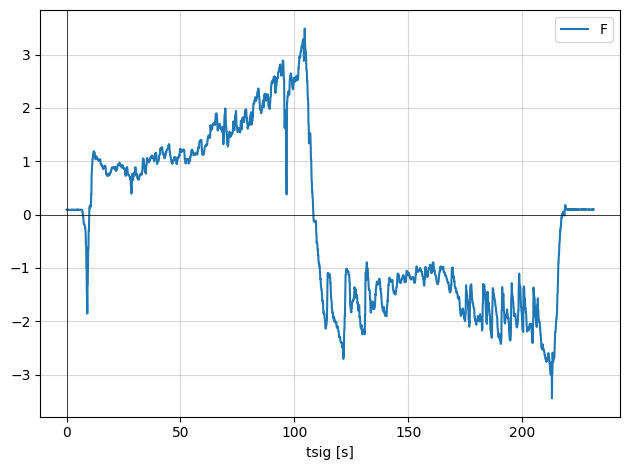

In [113]:
srate = 10  # 1/s
df0["tsig"] = (df0["Sample#"] - df0["Sample#"][0]) / srate
df0.plot(x="tsig", y="F", xlabel="tsig [s]")
ejes()

In [114]:
# Aislamiento de la señal
tsig = np.array(df0["tsig"])
sig = np.array(df0["F"])
n = len(sig)
print(f"{n=}")

# Gaussian window

k = 60  # s
ws = np.arange(-k, k+1)  # window samples

tgauss = ws / srate  # s
print(f'{tgauss=}')



n=2315

tgauss=array([-6. , -5.9, -5.8, -5.7, -5.6, -5.5, -5.4, -5.3, -5.2, -5.1, -5. ,
       -4.9, -4.8, -4.7, -4.6, -4.5, -4.4, -4.3, -4.2, -4.1, -4. , -3.9,
       -3.8, -3.7, -3.6, -3.5, -3.4, -3.3, -3.2, -3.1, -3. , -2.9, -2.8,
       -2.7, -2.6, -2.5, -2.4, -2.3, -2.2, -2.1, -2. , -1.9, -1.8, -1.7,
       -1.6, -1.5, -1.4, -1.3, -1.2, -1.1, -1. , -0.9, -0.8, -0.7, -0.6,
       -0.5, -0.4, -0.3, -0.2, -0.1,  0. ,  0.1,  0.2,  0.3,  0.4,  0.5,
        0.6,  0.7,  0.8,  0.9,  1. ,  1.1,  1.2,  1.3,  1.4,  1.5,  1.6,
        1.7,  1.8,  1.9,  2. ,  2.1,  2.2,  2.3,  2.4,  2.5,  2.6,  2.7,
        2.8,  2.9,  3. ,  3.1,  3.2,  3.3,  3.4,  3.5,  3.6,  3.7,  3.8,
        3.9,  4. ,  4.1,  4.2,  4.3,  4.4,  4.5,  4.6,  4.7,  4.8,  4.9,
        5. ,  5.1,  5.2,  5.3,  5.4,  5.5,  5.6,  5.7,  5.8,  5.9,  6. ])

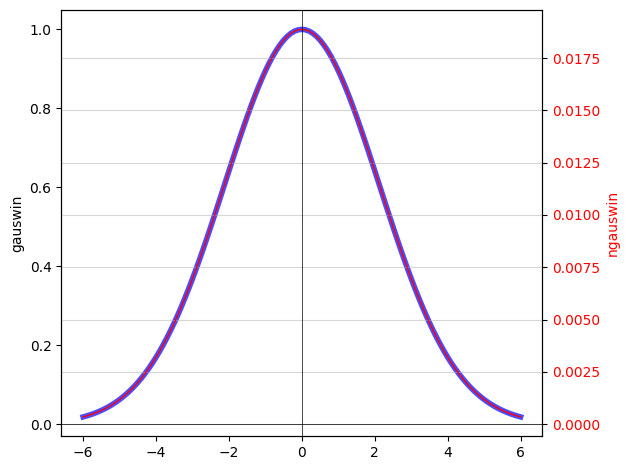

In [115]:
fwhm = 5  # s 

gauswin = np.exp(-(4 * np.log(2) * tgauss ** 2) / fwhm ** 2)

ngauswin = gauswin / np.sum(gauswin)

plt.plot(tgauss, gauswin, 'b', linewidth=4, alpha=0.7) # type: ignore
plt.ylabel('gauswin')
ax2 = plt.twinx()
ax2.plot(tgauss, ngauswin, 'r', linewidth=1) # type: ignore
ax2.set_ylabel('ngauswin', color='r')
ax2.tick_params(axis='y', labelcolor='r')
ejes()

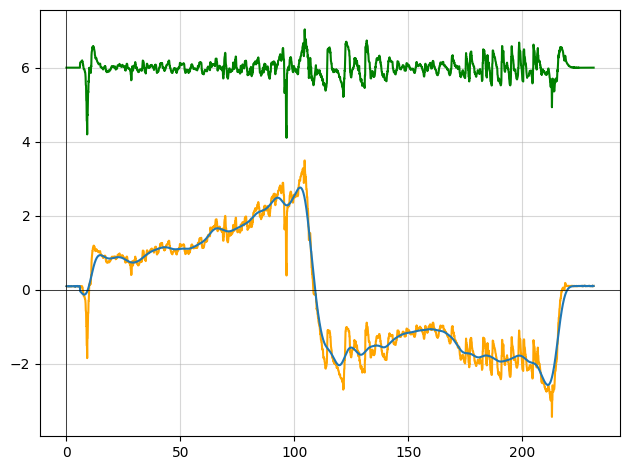

In [116]:
# apply the filter
fsig = sig.copy()

for i in range(k, n-k):  # i varía en todo el dominio de la señal, excepto en los extremos (a los que sí llega i-k cuando i=0 e i+k cuando i=n-k)
    fsig[i] = np.sum(sig[i-k : i+k+1]*ngauswin)
    
plt.plot(tsig, sig, color="orange")
plt.plot(tsig, fsig)
plt.plot(tsig, sig-fsig + 6, color="green")  

ejes()
plt.show()  

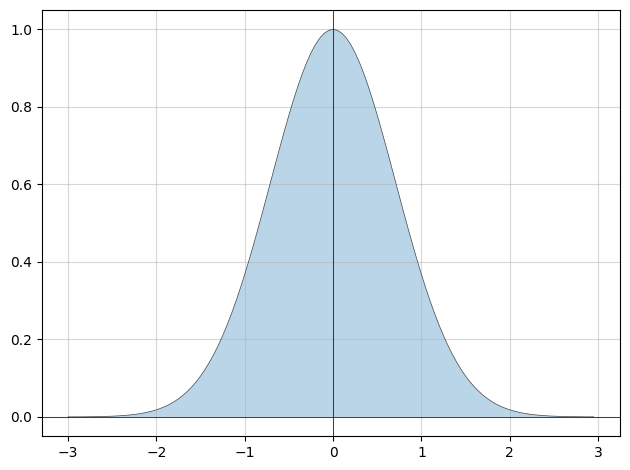

In [117]:
# Just a Gaussian
t = np.arange(-3, 3, 0.05)
y = np.exp(-t**2)
plt.fill_between(t, y, alpha=0.3)
plt.plot(t, y, 'k', linewidth=0.5, alpha=0.7) # type: ignore
ejes()

## Usando la función gaussian_filter()@myLib

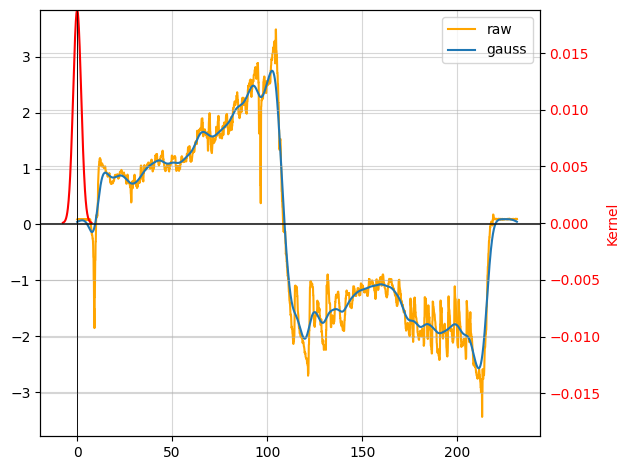

In [118]:
srate = 10 # 1/s

sw = 15# sec  (full window size = 2k+1 = 121 s)

f2 = sig.copy()

fwhm = 5.0 # sec

f2g, t_knl = gaussian_filter(f2, srate, fwhm, sw, return_kernel=True)  # apply the filter (filtered signal)
t, knl = t_knl

plt.ylim = (-5, 5)
plt.plot(tsig, sig, label="raw", color="orange")
plt.plot(tsig, f2g, label="gauss")
plt.legend(); ejes()



# Plot the kernel
ax2 = plt.twinx()
ymax = max(knl)
ax2.set_ylim(-ymax, ymax)
ax2.plot(t, knl, 'r') # type: ignore
ax2.set_ylabel('Kernel', color='r')
ax2.tick_params(axis='y', labelcolor='r')
ejes()

## Usando gaussian_filter1d @scipy.ndimage 

sigma=21.231422505307854

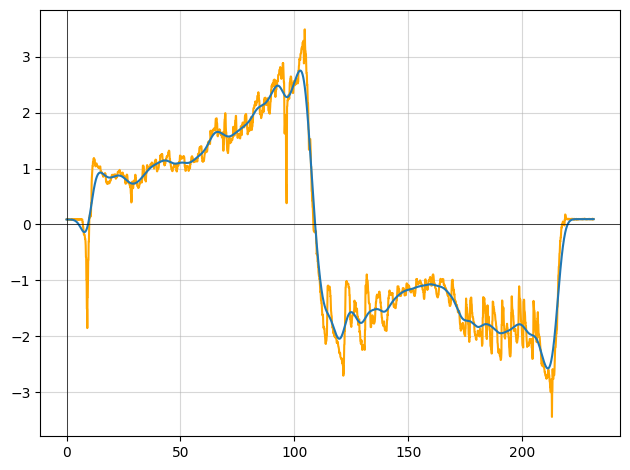

In [ ]:
fwhm = 5 # sec
srate = 10 # 1/sec

sigma = (fwhm * srate) / 2.355  # en muestras, sigma=21.2
print(f"{sigma=}")
truncate = 3  # ventana: [-3*sigma, 3*sigma]

# Filtrado
filtered_signal = gaussian_filter1d(sig, sigma=sigma, truncate=truncate)

plt.plot(tsig, sig, color='orange')
plt.plot(tsig, filtered_signal)
ejes()